# Analyzing Customer Behavior for E-commerce Insights
### Technical Assessment — Npontu Technologies | Intelligent Systems Services Engineer (NSS)


#### Project Overview
For this assessment, I’ve built out a churn analysis pipeline. I used a synthetic dataset (generated via Faker)as instructed to simulate customer behavior, specifically in a Ghanaian e-commerce retail context. My goal here was to see how browsing patterns, not just demographics, predict when a user is likely to churn.

#### Dataset Summary
| Property | Detail |
|---|---|
| **Rows** | 100,000 customers |
| **Columns** | 24 features |
| **Data covers** | Demographics, browsing behavior, purchase history, product interactions |
| **Target variable** | `churned` (1 = churned, 0 = retained) |
| **Churn rate** | ~26% |
| **Generated using** | Python — `faker`, `numpy`, `pandas` |


#### Pipeline Structure
| Step | Section | Description |
|---|---|---|
| 1 | Data Generation | Synthetic dataset with realistic embedded patterns |
| 2 | EDA | Structure, missing values, duplicates, distributions |
| 3 | Data Cleaning | Handle nulls, fix placeholders, correct data types |
| 4 | Feature Engineering | 9 new features + encoding + standardization |
| 5 | Predictive Modeling | Random Forest churn classifier + cross-validation |
| 6 | Big Data Tool | Apache Kafka pipeline simulation (Producer → Consumer) |
| 7 | Visualizations | 8 charts with business interpretation |
| 8 | Recommendations | 5 actionable business strategies |


#### Tools & Libraries Used
| Category | Tools Used |
|---|---|
| Data manipulation | `pandas`, `numpy` |
| Synthetic data | `faker` |
| Machine learning | `scikit-learn` (Random Forest, StandardScaler, train_test_split) |
| Big data simulation | `queue`, `threading`, `json` (Kafka simulation) |
| Visualization | `matplotlib`, `seaborn` |


**Submitted by:** Ekua Micah Abakah-Paintsil  
**Date:** May 2026  
**Role applied for:** Intelligent Systems Services Engineer (NSS)
 

### STEP 1 - DATA GENERATION

In [89]:
# Install required library 
!pip install faker

#Import relevant libraries
import pandas as pd
import numpy as np
from faker import Faker
import random

fake = Faker()
np.random.seed(42)
random.seed(42)

In [90]:
N = 100_000 

# Customer Demographics 
customer_ids = [f"CUST{str(i).zfill(6)}" for i in range(1, N+1)]
ages = np.random.normal(35, 12, N).clip(18, 75).astype(int)
genders = np.random.choice(['Male', 'Female', 'Non-binary'], N, p=[0.48, 0.48, 0.04])
locations = np.random.choice(
    ['Accra', 'Kumasi', 'Tamale', 'Takoradi', 'Cape Coast', 'Sunyani', 'Koforidua', 'Ho'],
    N, p=[0.35, 0.25, 0.10, 0.10, 0.08, 0.05, 0.04, 0.03]
)
membership_tiers = np.random.choice(
    ['Bronze', 'Silver', 'Gold', 'Platinum'], N, p=[0.50, 0.25, 0.15, 0.10]
)
account_creation_dates = [fake.date_between(start_date='-5y', end_date='-1m') for _ in range(N)]

# Browsing Behavior 
days_since_last_login = np.where(
    np.random.rand(N) < 0.3,               # 30% inactive → churn signal
    np.random.randint(60, 365, N),
    np.random.randint(1, 59, N)
)
num_sessions         = np.random.negative_binomial(3, 0.3, N).clip(1, 100)
avg_time_on_site_min = np.random.exponential(8, N).clip(1, 60).round(2)
pages_visited        = (num_sessions * np.random.uniform(2, 6, N)).astype(int).clip(1, 200)
device_types         = np.random.choice(['Mobile', 'Desktop', 'Tablet'], N, p=[0.60, 0.30, 0.10])

# Purchase History 
num_orders = np.where(
    days_since_last_login > 60,
    np.random.randint(0, 3, N),
    np.random.randint(1, 20, N)
).clip(0, 50)

avg_order_value = np.where(
    membership_tiers == 'Platinum', np.random.uniform(2000, 8000, N),
    np.where(membership_tiers == 'Gold',   np.random.uniform(1000, 4000, N),
    np.where(membership_tiers == 'Silver', np.random.uniform(500,  2000, N),
                                           np.random.uniform(100,  1000, N)))
).round(2)

total_spend              = (num_orders * avg_order_value).round(2)
payment_methods          = np.random.choice(
    ['Mobile Money', 'Credit Card', 'Debit Card', 'Cash on Delivery'],
    N, p=[0.45, 0.25, 0.20, 0.10]
)
days_since_last_purchase = np.where(num_orders == 0, 999, np.random.randint(1, 365, N))

# Product Interactions 
product_categories     = np.random.choice(
    ['Electronics', 'Fashion', 'Home & Living', 'Beauty', 'Sports', 'Food & Grocery', 'Books'],
    N, p=[0.25, 0.22, 0.15, 0.13, 0.10, 0.10, 0.05]
)
products_viewed        = (pages_visited * np.random.uniform(0.5, 1.5, N)).astype(int).clip(1, 300)
products_added_to_cart = (products_viewed * np.random.uniform(0.1, 0.4, N)).astype(int).clip(0, 50)
cart_abandonment_rate  = np.where(
    products_added_to_cart == 0, 0,
    (1 - (num_orders / (products_added_to_cart + 1))).clip(0, 1).round(3)
)
wishlist_items         = np.random.randint(0, 20, N)
avg_product_rating     = np.where(num_orders == 0, np.nan, np.random.uniform(2.5, 5.0, N).round(1))
reviews_left           = np.where(num_orders == 0, 0, (num_orders * np.random.uniform(0, 0.3, N)).astype(int))

# Churn Label (Target Variable) 
churn_score = (
    (days_since_last_login > 90).astype(int)  * 0.4 +
    (num_orders < 2).astype(int)               * 0.3 +
    (cart_abandonment_rate > 0.7).astype(int)  * 0.2 +
    (total_spend < 50).astype(int)             * 0.1
)
churned = (churn_score + np.random.normal(0, 0.1, N) > 0.45).astype(int)

# Assemble DataFrame 
df = pd.DataFrame({
    'customer_id'              : customer_ids,
    'age'                      : ages,
    'gender'                   : genders,
    'location'                 : locations,
    'membership_tier'          : membership_tiers,
    'account_creation_date'    : account_creation_dates,
    'days_since_last_login'    : days_since_last_login,
    'num_sessions'             : num_sessions,
    'avg_time_on_site_min'     : avg_time_on_site_min,
    'pages_visited'            : pages_visited,
    'device_type'              : device_types,
    'num_orders'               : num_orders,
    'avg_order_value_ghs'      : avg_order_value,
    'total_spend_ghs'          : total_spend,
    'days_since_last_purchase' : days_since_last_purchase,
    'payment_method'           : payment_methods,
    'preferred_category'       : product_categories,
    'products_viewed'          : products_viewed,
    'products_added_to_cart'   : products_added_to_cart,
    'cart_abandonment_rate'    : cart_abandonment_rate,
    'wishlist_items'           : wishlist_items,
    'avg_product_rating'       : avg_product_rating,
    'reviews_left'             : reviews_left,
    'churned'                  : churned
})

print(f"Dataset shape: {df.shape}")
print(f"\nChurn distribution:\n{df['churned'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()

Dataset shape: (100000, 24)

Churn distribution:
churned
0    74024
1    25976
Name: count, dtype: int64

Missing values:
avg_product_rating    9972
dtype: int64


,customer_id,age,gender,location,membership_tier,account_creation_date,days_since_last_login,num_sessions,avg_time_on_site_min,pages_visited,...,days_since_last_purchase,payment_method,preferred_category,products_viewed,products_added_to_cart,cart_abandonment_rate,wishlist_items,avg_product_rating,reviews_left,churned
0,CUST000001,40,Male,Sunyani,Bronze,2025-02-11,6,2,3.34,5,...,334,Debit Card,Fashion,3,1,0.500,11,4.6,0,0
1,CUST000002,33,Female,Kumasi,Bronze,2022-03-15,8,4,7.46,22,...,75,Mobile Money,Sports,28,4,0.000,9,3.9,1,0
2,CUST000003,42,Male,Kumasi,Bronze,2025-06-16,6,3,4.23,16,...,14,Mobile Money,Electronics,22,4,0.000,9,4.1,2,0
3,CUST000004,53,Female,Takoradi,Bronze,2022-02-15,208,3,19.20,10,...,287,Credit Card,Fashion,9,2,0.333,5,3.8,0,0
4,CUST000005,32,Male,Kumasi,Silver,2024-05-04,12,20,3.74,40,...,317,Mobile Money,Sports,32,8,0.000,19,4.4,3,0


In [91]:
df.to_csv('ecommerce_customer_data_ghs.csv', index=False)
print("Dataset saved as ecommerce_customer_data.csv")

Dataset saved as ecommerce_customer_data.csv


In [1]:
import pandas as pd
import numpy as np
from faker import Faker
import random

### STEP 2 - EXPLORATORY DATA ANALYSIS (EDA) 

In [15]:
# Loading the dataset 
df = pd.read_csv('ecommerce_customer_data_ghs.csv')

# Checking the shape 
print("Dataset Shape:", df.shape)

# Previewing the first 5 rows
df.head()

Dataset Shape: (100000, 24)


,customer_id,age,gender,location,membership_tier,account_creation_date,days_since_last_login,num_sessions,avg_time_on_site_min,pages_visited,...,days_since_last_purchase,payment_method,preferred_category,products_viewed,products_added_to_cart,cart_abandonment_rate,wishlist_items,avg_product_rating,reviews_left,churned
0,CUST000001,40,Male,Sunyani,Bronze,2025-02-11,6,2,3.34,5,...,334,Debit Card,Fashion,3,1,0.500,11,4.6,0,0
1,CUST000002,33,Female,Kumasi,Bronze,2022-03-15,8,4,7.46,22,...,75,Mobile Money,Sports,28,4,0.000,9,3.9,1,0
2,CUST000003,42,Male,Kumasi,Bronze,2025-06-16,6,3,4.23,16,...,14,Mobile Money,Electronics,22,4,0.000,9,4.1,2,0
3,CUST000004,53,Female,Takoradi,Bronze,2022-02-15,208,3,19.20,10,...,287,Credit Card,Fashion,9,2,0.333,5,3.8,0,0
4,CUST000005,32,Male,Kumasi,Silver,2024-05-04,12,20,3.74,40,...,317,Mobile Money,Sports,32,8,0.000,19,4.4,3,0


In [16]:
# Checking the data type of each column
print("Column Data Types:")
print(df.dtypes)

Column Data Types:
customer_id                  object
age                           int64
gender                       object
location                     object
membership_tier              object
account_creation_date        object
days_since_last_login         int64
num_sessions                  int64
avg_time_on_site_min        float64
pages_visited                 int64
device_type                  object
num_orders                    int64
avg_order_value_ghs         float64
total_spend_ghs             float64
days_since_last_purchase      int64
payment_method               object
preferred_category           object
products_viewed               int64
products_added_to_cart        int64
cart_abandonment_rate       float64
wishlist_items                int64
avg_product_rating          float64
reviews_left                  int64
churned                       int64
dtype: object


In [17]:
# Finding the number of missing values in each column
missing = df.isnull().sum()

# Showing columns that actually have missing values
missing_cols = missing[missing > 0]
print("Columns with Missing Values:")
print(missing_cols)
print(f"\nTotal missing values: {missing.sum()}")
print(f"{missing.sum() / df.size * 100:.2f}% of the entire dataset is missing")

Columns with Missing Values:
avg_product_rating    9972
dtype: int64

Total missing values: 9972
0.42% of the entire dataset is missing


In [18]:
# Checking for duplicate rows 
duplicate_count = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_count}")

# Since customer_id should be unique, it should be checked too
print(f"Unique customer IDs: {df['customer_id'].nunique()} out of {len(df)} rows")

Number of duplicate rows: 0
Unique customer IDs: 100000 out of 100000 rows


In [19]:
# Summary statistics for all numeric columns
print("Statistical Summary of Numeric Columns:")
df.describe().round(2)

Statistical Summary of Numeric Columns:


,age,days_since_last_login,num_sessions,avg_time_on_site_min,pages_visited,num_orders,avg_order_value_ghs,total_spend_ghs,days_since_last_purchase,products_viewed,products_added_to_cart,cart_abandonment_rate,wishlist_items,avg_product_rating,reviews_left,churned
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,90028.00,100000.00,100000.00
mean,34.98,83.84,7.04,8.04,27.64,7.33,1460.52,10700.60,263.97,27.14,6.27,0.32,9.51,3.75,0.74,0.26
std,11.14,97.36,4.79,7.91,21.52,6.18,1526.63,17169.13,264.16,23.78,6.64,0.39,5.77,0.72,1.15,0.44
min,18.00,1.00,1.00,1.00,2.00,0.00,100.03,0.00,1.00,1.00,0.00,0.00,0.00,2.50,0.00,0.00
25%,26.00,21.00,3.00,2.30,12.00,2.00,536.06,1244.68,102.00,10.00,2.00,0.00,5.00,3.10,0.00,0.00
50%,35.00,42.00,6.00,5.55,22.00,6.00,882.53,4599.25,203.00,21.00,4.00,0.00,10.00,3.80,0.00,0.00
75%,43.00,109.00,10.00,11.06,38.00,13.00,1765.88,12277.92,304.00,37.00,8.00,0.71,15.00,4.40,1.00,1.00
max,75.00,364.00,44.00,60.00,200.00,19.00,7998.82,150959.94,999.00,284.00,50.00,1.00,19.00,5.00,5.00,1.00


In [20]:
# Checking the distribution of each categorical column
categorical_cols = ['gender', 'location', 'membership_tier', 
                    'device_type', 'payment_method', 'preferred_category']

for col in categorical_cols:
    print(f"\n── {col.upper()} ──")
    print(df[col].value_counts())


── GENDER ──
gender
Female        48103
Male          47771
Non-binary     4126
Name: count, dtype: int64

── LOCATION ──
location
Accra         34995
Kumasi        24973
Tamale        10125
Takoradi       9970
Cape Coast     7971
Sunyani        4993
Koforidua      3904
Ho             3069
Name: count, dtype: int64

── MEMBERSHIP_TIER ──
membership_tier
Bronze      49991
Silver      25032
Gold        14953
Platinum    10024
Name: count, dtype: int64

── DEVICE_TYPE ──
device_type
Mobile     60192
Desktop    29793
Tablet     10015
Name: count, dtype: int64

── PAYMENT_METHOD ──
payment_method
Mobile Money        44945
Credit Card         25011
Debit Card          20069
Cash on Delivery     9975
Name: count, dtype: int64

── PREFERRED_CATEGORY ──
preferred_category
Electronics       24899
Fashion           22127
Home & Living     14885
Beauty            13086
Food & Grocery    10015
Sports             9941
Books              5047
Name: count, dtype: int64


In [21]:
# Checking how balanced the target variable (churned) is, as severe imbalance can mislead the model
print("Churn Distribution:")
print(df['churned'].value_counts())
print()
print("As percentages:")
print(df['churned'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

Churn Distribution:
churned
0    74024
1    25976
Name: count, dtype: int64

As percentages:
churned
0    74.02%
1    25.98%
Name: proportion, dtype: object


### STEP 3 - DATA CLEANING

In [22]:
# 1. Converting the account_creation_date column from string to proper datetime format. This enables future date calculations
df['account_creation_date'] = pd.to_datetime(df['account_creation_date'])
print("account_creation_date converted to datetime")

# 2. Handling missing values in avg_product_rating. These are customers with 0 orders: those who haven't rated anything
#    Filled these missing values with 0 to indicate "no rating given" rather than dropping the rows
df['avg_product_rating'] = df['avg_product_rating'].fillna(0)
print("avg_product_rating missing values filled with 0")

# 3. Handling the placeholder value of 999 in days_since_last_purchase, which was used to mark customers who never purchased
#    Replaced the 999 with the median of actual purchasers, which is a safer imputation than the mean, which is sensitive to outliers
actual_purchasers_median = df[df['days_since_last_purchase'] != 999]['days_since_last_purchase'].median()
df['days_since_last_purchase'] = df['days_since_last_purchase'].replace(999, actual_purchasers_median)
print(f"days_since_last_purchase placeholder (999) replaced with median: {actual_purchasers_median}")

# 4. Confirming no missing values remain
print(f"\nTotal missing values after cleaning: {df.isnull().sum().sum()}")

account_creation_date converted to datetime
avg_product_rating missing values filled with 0
days_since_last_purchase placeholder (999) replaced with median: 183.0

Total missing values after cleaning: 0


In [23]:
# Final check 
print("Final Dataset Shape:", df.shape)
print("\nData Types After Cleaning:")
print(df.dtypes)
df.head()

Final Dataset Shape: (100000, 24)

Data Types After Cleaning:
customer_id                         object
age                                  int64
gender                              object
location                            object
membership_tier                     object
account_creation_date       datetime64[ns]
days_since_last_login                int64
num_sessions                         int64
avg_time_on_site_min               float64
pages_visited                        int64
device_type                         object
num_orders                           int64
avg_order_value_ghs                float64
total_spend_ghs                    float64
days_since_last_purchase             int64
payment_method                      object
preferred_category                  object
products_viewed                      int64
products_added_to_cart               int64
cart_abandonment_rate              float64
wishlist_items                       int64
avg_product_rating                 

,customer_id,age,gender,location,membership_tier,account_creation_date,days_since_last_login,num_sessions,avg_time_on_site_min,pages_visited,...,days_since_last_purchase,payment_method,preferred_category,products_viewed,products_added_to_cart,cart_abandonment_rate,wishlist_items,avg_product_rating,reviews_left,churned
0,CUST000001,40,Male,Sunyani,Bronze,2025-02-11,6,2,3.34,5,...,334,Debit Card,Fashion,3,1,0.500,11,4.6,0,0
1,CUST000002,33,Female,Kumasi,Bronze,2022-03-15,8,4,7.46,22,...,75,Mobile Money,Sports,28,4,0.000,9,3.9,1,0
2,CUST000003,42,Male,Kumasi,Bronze,2025-06-16,6,3,4.23,16,...,14,Mobile Money,Electronics,22,4,0.000,9,4.1,2,0
3,CUST000004,53,Female,Takoradi,Bronze,2022-02-15,208,3,19.20,10,...,287,Credit Card,Fashion,9,2,0.333,5,3.8,0,0
4,CUST000005,32,Male,Kumasi,Silver,2024-05-04,12,20,3.74,40,...,317,Mobile Money,Sports,32,8,0.000,19,4.4,3,0


### Step 4 - FEATURE ENGINEERING 

In [24]:
# Set '2026-05-06' date as a reference point for all date calculations
today = pd.Timestamp('2026-05-06')

# Generally, it is assumed that older accounts tend to be more loyal and less likely to churn
df['account_age_days']  = (today - df['account_creation_date']).dt.days
df['account_age_years'] = (df['account_age_days'] / 365).round(2)

print("Time-based features created")
print(df[['account_creation_date', 'account_age_days', 'account_age_years']].head())

Time-based features created
  account_creation_date  account_age_days  account_age_years
0            2025-02-11               449               1.23
1            2022-03-15              1513               4.15
2            2025-06-16               324               0.89
3            2022-02-15              1541               4.22
4            2024-05-04               732               2.01


In [25]:
# Grouped customers into age brackets instead of using raw ages
# Age groups are easier for the model to generalize from and are more interpretable for business recommendations
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 25, 35, 45, 60, 75],
    labels=['18-25', '26-35', '36-45', '46-60', '61-75']
)

print("Age group feature created:")
print(df['age_group'].value_counts()) 

Age group feature created:
age_group
26-35    30570
36-45    28647
18-25    22702
46-60    16554
61-75     1527
Name: count, dtype: int64


In [26]:
# Dividing orders by account age in months gives purchase frequency and a declining frequency is a strong churn signal
df['purchase_frequency'] = np.where(df['account_age_days'] > 0,(df['num_orders'] / (df['account_age_days'] / 30)).round(4),0)

# Calculating the revenue generated by customer per session. It is assused that a high revenue per session indicates highly engaged, valuable customer
df['revenue_per_session'] = (df['total_spend_ghs'] / df['num_sessions']).round(2)

# Calculating the fraction of products viewed that actually led to a purchase. A low ratio would mean that a customer browses 
# but doesn't purchase - churn risk. +1 is included in denominator to prevent division by zero.
df['browse_to_purchase_ratio'] = (df['num_orders'] / (df['products_viewed'] + 1)).round(4)

print("Purchase behavior features created:")
print(df[['purchase_frequency', 'revenue_per_session', 'browse_to_purchase_ratio']].describe().round(3))

Purchase behavior features created:
       purchase_frequency  revenue_per_session  browse_to_purchase_ratio
count          100000.000           100000.000                100000.000
mean                1.021             2755.774                     0.558
std                 9.402             6762.470                     0.940
min                 0.000                0.000                     0.000
25%                 0.054              192.810                     0.067
50%                 0.217              788.100                     0.246
75%                 0.483             2488.070                     0.630
max               540.000           144495.950                     9.500


In [27]:
# Calculated a Composite engagement score by combining 3 signals into one metric:
# - Recency  (40%): how recently a customer logged in (if it is more recent,there is a higher score)
# - Frequency (30%): how many sessions a customer had relative to the maximum number of sessions
# - Duration  (30%): how long a customer spends on the platform relative to the maximum number of minutes spent on the platform
# The final score ranges from 0 (disengaged customer) to ~1 (highly engaged customer)

df['engagement_score'] = (
    (1 / (df['days_since_last_login'] + 1))              * 0.4 +
    (df['num_sessions'] / df['num_sessions'].max())       * 0.3 +
    (df['avg_time_on_site_min'] / df['avg_time_on_site_min'].max()) * 0.3
).round(4)

print("Engagement score created:")
print(df['engagement_score'].describe().round(4))

Engagement score created:
count    100000.0000
mean          0.1069
std           0.0593
min           0.0129
25%           0.0641
50%           0.0950
75%           0.1360
max           0.5240
Name: engagement_score, dtype: float64


In [28]:
# Created a binary feature (1 = high value, 0 = not) to flag customers in the top 25% of total spend as "high value" Which is useful for 
#segmentation and targeted retention strategies.
spend_threshold = df['total_spend_ghs'].quantile(0.75)
df['is_high_value'] = (df['total_spend_ghs'] > spend_threshold).astype(int)

print(f"High value flag created (threshold: GH₵{spend_threshold:.2f})")
print(df['is_high_value'].value_counts())

High value flag created (threshold: GH₵12277.92)
is_high_value
0    75000
1    25000
Name: count, dtype: int64


In [29]:
# Converted the membership tier (which is text) into an ordered numeric score: Bronze=1, Silver=2, Gold=3, Platinum=4 preserving the natural ranking
#of tiers for the model.
tier_map = {'Bronze': 1, 'Silver': 2, 'Gold': 3, 'Platinum': 4}
df['loyalty_score'] = df['membership_tier'].map(tier_map)

print("Loyalty score created:")
print(df.groupby('membership_tier')['loyalty_score'].first())

Loyalty score created:
membership_tier
Bronze      1
Gold        3
Platinum    4
Silver      2
Name: loyalty_score, dtype: int64


In [30]:
from sklearn.preprocessing import LabelEncoder

# Machine learning models can't work with text directly
# Label encoding converts each unique category in a column to a number e.g. 'Accra'=0, 'Cape Coast'=1, 'Ho'=2, etc. Label encoding is used when 
#categories in a column have no inherent order.
le = LabelEncoder()

categorical_cols = ['gender', 'location', 'device_type', 
                    'payment_method', 'preferred_category', 'age_group']

for col in categorical_cols:
    
    df[f'{col}_encoded'] = le.fit_transform(df[col].astype(str))
    print(f" {col} encoded")
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(mapping)
    
print("\nSample of encoded columns:")
df[['gender', 'gender_encoded', 'location', 'location_encoded']].head()

 gender encoded
{'Female': np.int64(0), 'Male': np.int64(1), 'Non-binary': np.int64(2)}
 location encoded
{'Accra': np.int64(0), 'Cape Coast': np.int64(1), 'Ho': np.int64(2), 'Koforidua': np.int64(3), 'Kumasi': np.int64(4), 'Sunyani': np.int64(5), 'Takoradi': np.int64(6), 'Tamale': np.int64(7)}
 device_type encoded
{'Desktop': np.int64(0), 'Mobile': np.int64(1), 'Tablet': np.int64(2)}
 payment_method encoded
{'Cash on Delivery': np.int64(0), 'Credit Card': np.int64(1), 'Debit Card': np.int64(2), 'Mobile Money': np.int64(3)}
 preferred_category encoded
{'Beauty': np.int64(0), 'Books': np.int64(1), 'Electronics': np.int64(2), 'Fashion': np.int64(3), 'Food & Grocery': np.int64(4), 'Home & Living': np.int64(5), 'Sports': np.int64(6)}
 age_group encoded
{'18-25': np.int64(0), '26-35': np.int64(1), '36-45': np.int64(2), '46-60': np.int64(3), '61-75': np.int64(4)}

Sample of encoded columns:


,gender,gender_encoded,location,location_encoded
0,Male,1,Sunyani,5
1,Female,0,Kumasi,4
2,Male,1,Kumasi,4
3,Female,0,Takoradi,6
4,Male,1,Kumasi,4


In [31]:
from sklearn.preprocessing import StandardScaler

# Standardization rescales numeric columns to have a mean=0 and a standard deviation =1
# This prevents columns with large values (like total_spend_ghs) from dominating columns with small values (like avg_product_rating).
# I created a scaled copy to keep the original df dataset intact

numeric_cols = [
    'age', 'days_since_last_login', 'num_sessions', 'avg_time_on_site_min',
    'pages_visited', 'num_orders', 'avg_order_value_ghs', 'total_spend_ghs',
    'days_since_last_purchase', 'products_viewed', 'products_added_to_cart',
    'cart_abandonment_rate', 'wishlist_items', 'avg_product_rating', 'reviews_left',
    'account_age_days', 'purchase_frequency', 'revenue_per_session',
    'browse_to_purchase_ratio', 'engagement_score'
]

scaler    = StandardScaler()
df_scaled = df.copy()   # to keep the original df intact
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Standardization complete")
print(f"Scaled dataset shape: {df_scaled.shape}")
print("\nSample of scaled values (mean ≈ 0, std ≈ 1):")
df_scaled[numeric_cols[:4]].describe().round(3)

Standardization complete
Scaled dataset shape: (100000, 39)

Sample of scaled values (mean ≈ 0, std ≈ 1):


,age,days_since_last_login,num_sessions,avg_time_on_site_min
count,100000.000,100000.000,100000.000,100000.000
mean,-0.000,0.000,-0.000,0.000
std,1.000,1.000,1.000,1.000
min,-1.523,-0.851,-1.261,-0.891
25%,-0.805,-0.646,-0.843,-0.726
50%,0.002,-0.430,-0.218,-0.315
75%,0.720,0.258,0.616,0.381
max,3.591,2.878,7.708,6.569


In [34]:
# This is to print a summary of every feature engineered 
new_features = {
    'account_age_days'         : 'How long the customer has had an account (in days)',
    'account_age_years'        : 'Account age in years',
    'age_group'                : 'Customer age put into 5 buckets',
    'purchase_frequency'       : 'Average number of orders per month',
    'revenue_per_session'      : 'Average revenue generated each time a customer visits',
    'browse_to_purchase_ratio' : 'Fraction of viewed products that led to a purchase',
    'engagement_score'         : 'Composite score combining recency, frequency & duration',
    'is_high_value'            : 'Binary flag: top 25% spenders = 1(high value), others = 0',
    'loyalty_score'            : 'Membership tier converted to ordered numeric (1–4)',
    'encoded columns'        : 'Categorical columns converted to numbers for modeling'
}

print(f"{'Feature':<30} {'Description'}")
print("─" * 80)
for feat, desc in new_features.items():
    print(f"{feat:<30} {desc}")

print(f"\nTotal columns after feature engineering: {df.shape[1]}")

Feature                        Description
────────────────────────────────────────────────────────────────────────────────
account_age_days               How long the customer has had an account (in days)
account_age_years              Account age in years
age_group                      Customer age put into 5 buckets
purchase_frequency             Average number of orders per month
revenue_per_session            Average revenue generated each time a customer visits
browse_to_purchase_ratio       Fraction of viewed products that led to a purchase
engagement_score               Composite score combining recency, frequency & duration
is_high_value                  Binary flag: top 25% spenders = 1(high value), others = 0
loyalty_score                  Membership tier converted to ordered numeric (1–4)
encoded columns                Categorical columns converted to numbers for modeling

Total columns after feature engineering: 39


### STEP 5: PREDICTIVE MODELING — CUSTOMER CHURN PREDICTION 

In [35]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,roc_auc_score, accuracy_score)

#Columns excluded in predictive model: customer_id, churned (target-Y), raw text columns (encoded versions are used instead), and the date column as well
feature_cols = [
    'age', 'days_since_last_login', 'num_sessions', 'avg_time_on_site_min',
    'pages_visited', 'num_orders', 'avg_order_value_ghs', 'total_spend_ghs',
    'days_since_last_purchase', 'products_viewed', 'products_added_to_cart',
    'cart_abandonment_rate', 'wishlist_items', 'avg_product_rating', 'reviews_left',
    'account_age_days', 'purchase_frequency', 'revenue_per_session',
    'browse_to_purchase_ratio', 'engagement_score', 'is_high_value', 'loyalty_score',
    'gender_encoded', 'location_encoded', 'device_type_encoded',
    'payment_method_encoded', 'preferred_category_encoded'
]

X = df[feature_cols]   # features
y = df['churned']      # target variable (1 = churned, 0 = retained)

print(f"Features: {X.shape[1]} columns")
print(f"Samples : {X.shape[0]} rows")
print(f"\nTarget distribution:\n{y.value_counts()}")

Features: 27 columns
Samples : 100000 rows

Target distribution:
churned
0    74024
1    25976
Name: count, dtype: int64


In [36]:
# Splitting the data into 80% training and 20% testing
#stratify=y ensures both splits have almost the same churn ratio. This is important so the test set is representative original dataset’s class distribution.
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2, random_state=42,stratify=y)

print(f"Training set : {X_train.shape[0]} rows")
print(f"Testing set  : {X_test.shape[0]} rows")
print(f"\nChurn rate in training set : {y_train.mean():.2%}")
print(f"Churn rate in testing set  : {y_test.mean():.2%}")

Training set : 80000 rows
Testing set  : 20000 rows

Churn rate in training set : 25.98%
Churn rate in testing set  : 25.97%


In [37]:
# I used a Random Forest Classifier, which is an ensemble of decision trees, and it works by building different trees (in this case,100 trees) 
# and taking a majority vote
# I selected Random Forest as my predictive model because:
#   - It handles non-linear relationships efficiently
#   - It is robust to outliers (since the dataset is synthetic and generated using Faker and numpy,it may contain noise and outliers)
#   - It gives feature importance scores (which will help identify why churners churn in this case)
#   - It does not require feature scaling
# The StandardScaler created earlier is preserved for any future model comparisons.

rf_model = RandomForestClassifier(
    n_estimators=100,   # build 100 decision trees
    max_depth=10,       # limit tree depth to prevent overfitting
    random_state=42,    # for reproducibility
    n_jobs=-1           # use all CPU cores to train faster
)

rf_model.fit(X_train, y_train)
print(" Random Forest model trained successfully")
print(f"  Trees built    : {rf_model.n_estimators}")
print(f"  Max tree depth : {rf_model.max_depth}")
print(f"  Features used  : {rf_model.n_features_in_}")

 Random Forest model trained successfully
  Trees built    : 100
  Max tree depth : 10
  Features used  : 27


In [38]:
# Generating the predictions on the test set
y_pred = rf_model.predict(X_test)          # class prediction (0 or 1)
y_prob = rf_model.predict_proba(X_test)[:, 1]  # probability of churn

# [:, 1] selects the probability of the positive class (churned=1)
print("Predictions generated:")
print(f"Predicted churners    : {y_pred.sum():,}")
print(f"Actual churners       : {y_test.sum():,}")

Predictions generated:
Predicted churners    : 5,130
Actual churners       : 5,195


In [39]:
# The Classification report shows 4 metrics per class:
# Precision  — of all predicted churners, how many actually churned?
# Recall     — of all actual churners, how many did the model catch?
# F1-score   — harmonic mean of precision and recall (balance of both)
# Support    — how many samples of each class in the test set

print("=== CLASSIFICATION REPORT ===\n")
print(classification_report(y_test, y_pred, target_names=['Retained (0)', 'Churned (1)']))

=== CLASSIFICATION REPORT ===

              precision    recall  f1-score   support

Retained (0)       0.98      0.98      0.98     14805
 Churned (1)       0.95      0.94      0.94      5195

    accuracy                           0.97     20000
   macro avg       0.96      0.96      0.96     20000
weighted avg       0.97      0.97      0.97     20000



In [40]:
# A general Confusion Matrix shows:
# True Positives — number of positive class observations the model correctly predicted (in this case: 'Churners',
# because that is what is being predicted)
# False Positives — retained customers wrongly flagged as churners
# False Negatives — churners who were missed (churners wrongly flagged as retained customers)
# True Negatives — number of negative class observations the model correctly predicted ( in this case: 'Retained')

In [41]:
cm = confusion_matrix(y_test, y_pred)

print("=== CONFUSION MATRIX ===\n")
print(f"{'':20} Predicted Retained   Predicted Churned")
print(f"Actual Retained   {cm[0][0]:>14,}         {cm[0][1]:>14,}")
print(f"Actual Churned    {cm[1][0]:>14,}         {cm[1][1]:>14,}")

tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Positives  (correctly caught churners) : {tp:,}")
print(f"False Negatives (churners we missed)        : {fn:,}")
print(f"False Positives (wrongly flagged as churner): {fp:,}")
print(f"True Negatives  (correctly identified as retained): {tn:,}")

=== CONFUSION MATRIX ===

                     Predicted Retained   Predicted Churned
Actual Retained           14,541                    264
Actual Churned               329                  4,866

True Positives  (correctly caught churners) : 4,866
False Negatives (churners we missed)        : 329
False Positives (wrongly flagged as churner): 264
True Negatives  (correctly identified as retained): 14,541


In [42]:
# The ROC-AUC measures how well the model separates churners from non-churners
# The score ranges from 0.5 (random guessing) to 1.0 (perfect separation) and above 0.90 is considered excellent

accuracy = accuracy_score(y_test, y_pred)
roc_auc  = roc_auc_score(y_test, y_prob)

print("=== OVERALL MODEL PERFORMANCE ===\n")
print(f"Accuracy  : {accuracy:.2%}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print()
if roc_auc >= 0.95:
    print(" Excellent model. The model has a strong ability to distinguish churners from retained customers")
elif roc_auc >= 0.90:
    print(" Good model. The models churn predictions are reliable")
else:
    print(" The model needs improvement hence its churn predictions cannot be relied on.")

=== OVERALL MODEL PERFORMANCE ===

Accuracy  : 97.04%
ROC-AUC   : 0.9955

 Excellent model. The model has a strong ability to distinguish churners from retained customers


In [43]:
#The ROC-AUC score is near-perfect, which is likely because the dataset is synthetic with clear behavioral signals. 
#In a real-world setting with more 'messy' human behavior, the ROC-AUC score may be closer to 0.85-0.90.

In [44]:
# Cross-validation tests the model on 5 different splits of training data
# This is used to ensure that the model can actually work on new unseen data rather than just memorizing the training data.
# StratifiedKFold preserves the churn ratio across all 5 folds, that is, it keeps the same proportion of churners and retainers in every fold.

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=cv, scoring='roc_auc')

print("=== 5-FOLD CROSS VALIDATION ===\n")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: ROC-AUC = {score:.4f}")

print(f"\n  Mean ROC-AUC : {cv_scores.mean():.4f}")
print(f"  Std Dev      : {cv_scores.std():.4f}")
print(f"\n Consistent performance across all folds — model is stable and not overfitting")

=== 5-FOLD CROSS VALIDATION ===

  Fold 1: ROC-AUC = 0.9953
  Fold 2: ROC-AUC = 0.9954
  Fold 3: ROC-AUC = 0.9957
  Fold 4: ROC-AUC = 0.9956
  Fold 5: ROC-AUC = 0.9949

  Mean ROC-AUC : 0.9954
  Std Dev      : 0.0003

 Consistent performance across all folds — model is stable and not overfitting


In [45]:
# Random Forest helps determine which features it relied on most to make decisions
# A higher importance indicates that the feature is more useful for predicting churn
# This is valuable for business as it indicates what DRIVES churn.

importances = pd.Series(
    rf_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=False)

print("=== TOP 10 MOST IMPORTANT FEATURES ===\n")
for i, (feat, score) in enumerate(importances.head(10).items(), 1):
    bar = '█' * int(score * 100)
    print(f"{i:>2}. {feat:<30} {score:.4f}  {bar}")

print("\n── Business Interpretation ──")
print("days_since_last_login    - Inactivity is the number 1 churn predictor")
print("num_orders               - Low purchase count = high churn risk")
print("cart_abandonment_rate    - Browsing without buying signals disengagement")
print("browse_to_purchase_ratio - Low conversion = customer losing interest")
print("purchase_frequency       - Declining buying frequency warns of churn")

=== TOP 10 MOST IMPORTANT FEATURES ===

 1. days_since_last_login          0.3433  ██████████████████████████████████
 2. num_orders                     0.1877  ██████████████████
 3. cart_abandonment_rate          0.1317  █████████████
 4. browse_to_purchase_ratio       0.1087  ██████████
 5. purchase_frequency             0.0547  █████
 6. revenue_per_session            0.0496  ████
 7. total_spend_ghs                0.0430  ████
 8. avg_product_rating             0.0140  █
 9. products_added_to_cart         0.0140  █
10. reviews_left                   0.0138  █

── Business Interpretation ──
days_since_last_login    - Inactivity is the number 1 churn predictor
num_orders               - Low purchase count = high churn risk
cart_abandonment_rate    - Browsing without buying signals disengagement
browse_to_purchase_ratio - Low conversion = customer losing interest
purchase_frequency       - Declining buying frequency warns of churn


### STEP 6: BIG DATA TOOL — APACHE KAFKA SIMULATION

#### Why I chose Apache Kafka
I chose Apache Kafka because modern e-commerce does not happen in batches. In a live environment, static snapshots of the past are not what is sought; rather, a constant stream of customer decisions is what is dealt with. By using Kafka, I'm simulating a system that can catch a customer's 'frustration signals', like repeated page refreshes or cart abandonment as they happen, allowing for intervention before their browser is closed.
From my research, **Apache Kafka** is the industry-standard tool for handling exactly this kind of real-time event streaming. 

Apache Kafka is a fit for this case scenario for the following reasons:

| Reason | Explanation |
|---|---|
| **Real-time ingestion** | Kafka captures clickstream events the moment they happen |
| **Scalability** | It handles millions of events per second across distributed servers |
| **Decoupling** | Producers (the platform) and Consumers (analytics pipeline) work independently |
| **Fault tolerance** | Messages are persisted on disk hence no data is lost if a consumer crashes |
| **Churn detection** | It enables real-time alerts when a customer shows churn signals |

#### Simulation
Since this is a local environment, Kafka is simulated using Python's built-in `queue` and `threading` modules:
- `queue.Queue` acts as the **Kafka topic** (the message channel)
- A **Producer thread** sends customer events into the queue
- A **Consumer thread** reads and processes events simultaneously
- Both run in parallel just exactly as Kafka's architecture works

In [46]:
import queue        # acts as the Kafka topic (message broker)
import threading    # runs producer and consumer in parallel
import time         # adds slight delay to simulate real-time streaming
import json         # messages are sent as JSON strings (as in real Kafka)
from datetime import datetime

# Creating a sample of 20 customer events from the dataset
# In actual production, these would be live events from the platform
sample_customers = df.sample(20, random_state=42)[['customer_id', 'age', 'location', 'total_spend_ghs', 'days_since_last_login']].copy()

# Adding event types to help simulate different customer actions on the platform
import random
random.seed(42)
event_types = ['page_view', 'add_to_cart', 'purchase', 'session_start']
sample_customers['event_type'] = [random.choice(event_types) for _ in range(20)]
sample_customers['timestamp']  = datetime.now().isoformat()

# Converting to a list of dictionaries for easy JSON serialization
customer_events = sample_customers.to_dict(orient='records')

print(f"{len(customer_events)} customer events ready for streaming")
print("\nSample event:")
print(json.dumps(customer_events[0], indent=2))

20 customer events ready for streaming

Sample event:
{
  "customer_id": "CUST075722",
  "age": 38,
  "location": "Accra",
  "total_spend_ghs": 1155.87,
  "days_since_last_login": 82,
  "event_type": "page_view",
  "timestamp": "2026-05-08T13:11:03.590264"
}


In [47]:
# Simulate the kafka topic with a thread-safe Python Queue
# maxsize=100 means the topic holds up to 100 unprocessed messages at once

kafka_topic     = queue.Queue(maxsize=100)
processed_events = []               # stores events after consumer processes them
producer_done   = threading.Event() # signal so consumer knows when to stop

print(" Kafka topic 'ecommerce_events' initialized")

 Kafka topic 'ecommerce_events' initialized


In [48]:
def kafka_producer(events):
    """
    Simulates a Kafka Producer.
    In real Kafka, this would be the e-commerce website
    publishing events every time a customer does something.
    """
    print("[ PRODUCER ] Starting — publishing to topic: ecommerce_events")
    print("─" * 65)

    for i, event in enumerate(events):
        # Serializing the event to JSON (how Kafka transmits messages)
        message = json.dumps(event)

        # Putting the message into the topic (queue)
        kafka_topic.put(message)

        print(f"[ PRODUCER ] Sent {i+1:>2}/{len(events)} | "
              f"customer: {event['customer_id']} | "
              f"event: {event['event_type']}")

        # Small delay simulates events arriving over time
        time.sleep(0.05)

    # Signal to consumer that all events have been sent
    producer_done.set()
    print("\n[ PRODUCER ]  All events published.\n")

In [49]:
def kafka_consumer():
    """
    Simulates a Kafka Consumer.
    In real Kafka, this would be the analytics pipeline
    reading events and processing them in real time.
    Here it assigns a churn risk level to each incoming event.
    """
    print("[ CONSUMER ] Listening on topic: ecommerce_events")
    print("─" * 65)

    while not (producer_done.is_set() and kafka_topic.empty()):
        try:
            # Reading one message from the topic
            message = kafka_topic.get(timeout=0.5)
            event   = json.loads(message)

            # Real-time churn risk scoring
            # This is what a streaming ML pipeline would do in production
            if event['days_since_last_login'] > 90 and event['total_spend_ghs'] < 500:
                event['churn_risk'] = 'HIGH'
            elif event['days_since_last_login'] > 45:
                event['churn_risk'] = 'MEDIUM'
            else:
                event['churn_risk'] = 'LOW'

            # Storing the enriched event
            processed_events.append(event)

            print(f"[ CONSUMER ] Processed: {event['customer_id']} | "
                  f"event: {event['event_type']:<14} | "
                  f"churn_risk: {event['churn_risk']}")

            # Marking message as done
            kafka_topic.task_done()

        except queue.Empty:
            # No message right now — keep waiting
            continue

    print("\n[ CONSUMER ]  All events processed.")

In [50]:
# Launching the Producer and Consumer on separate threads
# This is the key feature of Kafka — both run simultaneously. The consumer doesn't wait for the producer to finish before starting

consumer_thread = threading.Thread(target=kafka_consumer)
producer_thread = threading.Thread(target=kafka_producer, args=(customer_events,))

# Starting consumer first so it's ready to receive immediately
consumer_thread.start()
producer_thread.start()

# Waiting for both threads to complete before moving on
producer_thread.join()
consumer_thread.join()

[ CONSUMER ] Listening on topic: ecommerce_events
─────────────────────────────────────────────────────────────────
[ PRODUCER ] Starting — publishing to topic: ecommerce_events
─────────────────────────────────────────────────────────────────
[ PRODUCER ] Sent  1/20 | customer: CUST075722 | event: page_view
[ CONSUMER ] Processed: CUST075722 | event: page_view      | churn_risk: MEDIUM
[ PRODUCER ] Sent  2/20 | customer: CUST080185 | event: page_view
[ CONSUMER ] Processed: CUST080185 | event: page_view      | churn_risk: LOW
[ PRODUCER ] Sent  3/20 | customer: CUST019865 | event: purchase
[ CONSUMER ] Processed: CUST019865 | event: purchase       | churn_risk: MEDIUM
[ PRODUCER ] Sent  4/20 | customer: CUST076700 | event: add_to_cart
[ CONSUMER ] Processed: CUST076700 | event: add_to_cart    | churn_risk: LOW
[ PRODUCER ] Sent  5/20 | customer: CUST092992 | event: add_to_cart[ CONSUMER ] Processed: CUST092992 | event: add_to_cart    | churn_risk: MEDIUM

[ PRODUCER ] Sent  6/20 | cus

In [51]:
# Converting processed events into a DataFrame for analysis
df_stream = pd.DataFrame(processed_events)

print("=== KAFKA STREAM PROCESSING SUMMARY ===\n")
print(f"Total events processed : {len(df_stream)}")

print(f"\nChurn Risk Distribution:")
print(df_stream['churn_risk'].value_counts())

print(f"\nEvents by Type:")
print(df_stream['event_type'].value_counts())

print(f"\nHIGH RISK customers flagged in real time:")
high_risk = df_stream[df_stream['churn_risk'] == 'HIGH'][
    ['customer_id', 'event_type', 'total_spend_ghs', 'days_since_last_login', 'churn_risk']
]
print(high_risk if len(high_risk) > 0 else "None in this sample")

print("\n In production, HIGH RISK customers would immediately trigger a retention campaign such as discount email, loyalty reward, or push notification.")

=== KAFKA STREAM PROCESSING SUMMARY ===

Total events processed : 20

Churn Risk Distribution:
churn_risk
MEDIUM    11
LOW        9
Name: count, dtype: int64

Events by Type:
event_type
page_view        8
add_to_cart      7
session_start    3
purchase         2
Name: count, dtype: int64

HIGH RISK customers flagged in real time:
None in this sample

 In production, HIGH RISK customers would immediately trigger a retention campaign such as discount email, loyalty reward, or push notification.


### STEP 7 - INSIGHTS & VISUALIZATIONS

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

#### CUSTOMER CHURN DISTRIBUTION

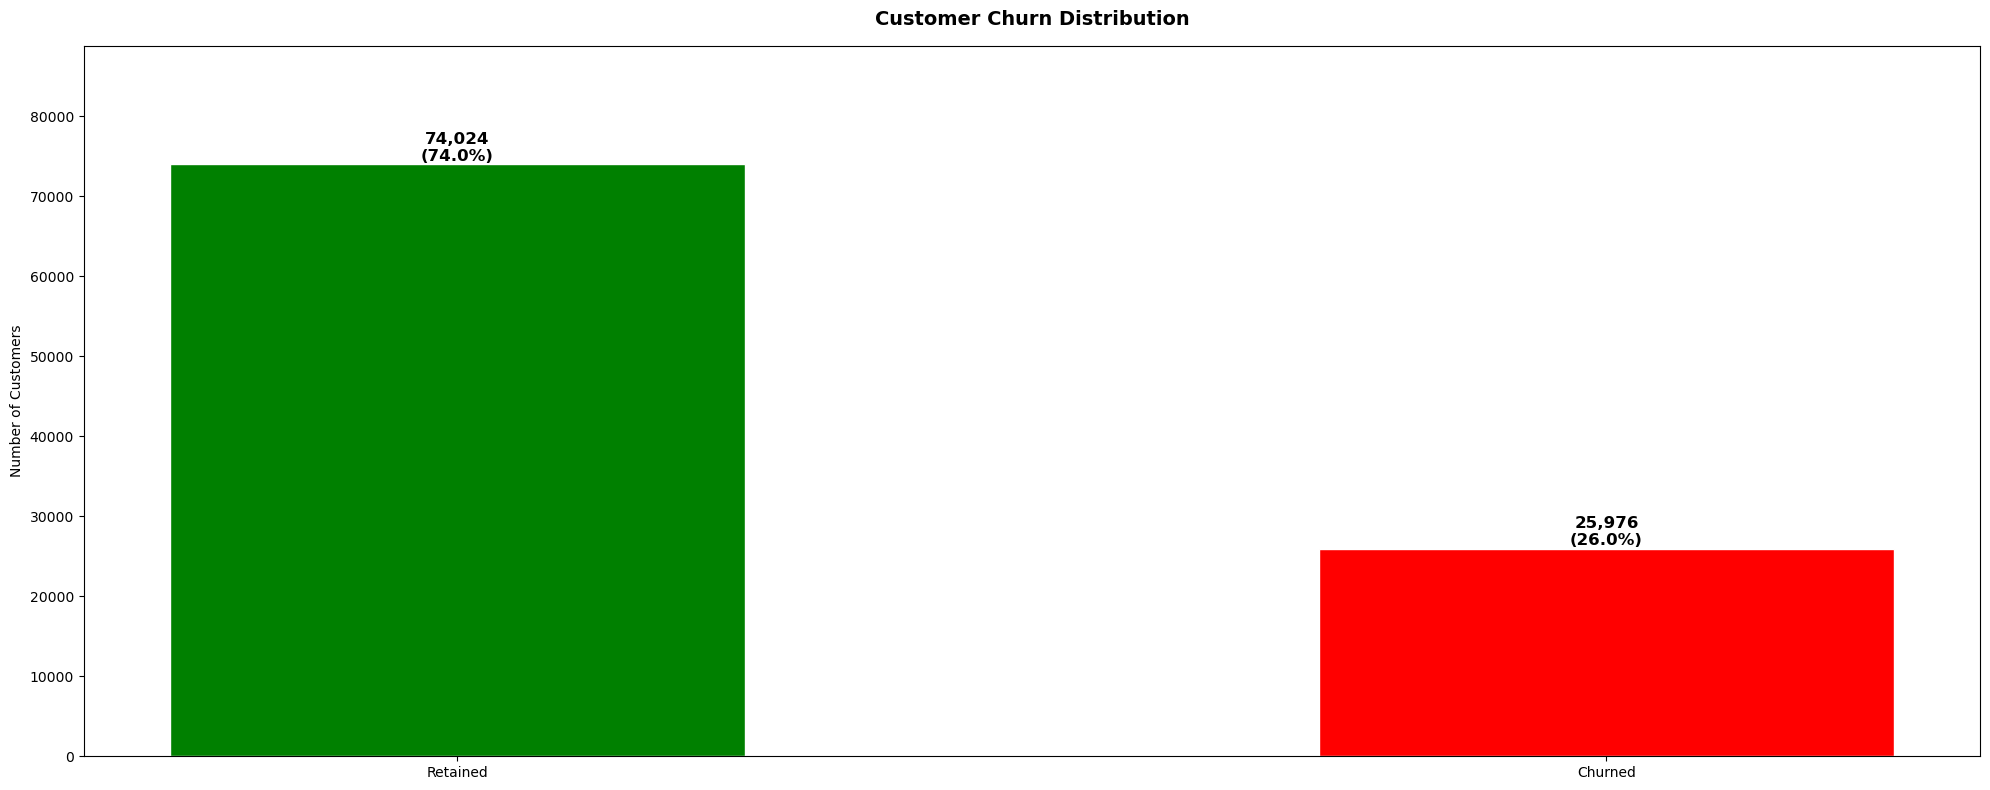


 INSIGHT 1:
  26.0% of customers have churned.
  A 26% churn rate suggests that a quarter of customer base is being lost. It suggests that current engagement efforts are not 
retaining customers, hence, proactive retention strategies must be put in place.


In [53]:
fig, ax = plt.subplots(figsize=(20, 8))

churn_counts = df['churned'].value_counts()
labels       = ['Retained', 'Churned']
colors       = ['green', 'red']

bars = ax.bar(labels, churn_counts.values, color=colors, width=0.5, edgecolor='white')

# Adding count and percentage labels on top of each bar
for bar, count in zip(bars, churn_counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 400,
            f'{count:,}\n({pct:.1f}%)',
            ha='center', fontsize=12, fontweight='bold')

ax.set_title('Customer Churn Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Customers')
ax.set_ylim(0, churn_counts.max() * 1.2)
plt.tight_layout()
ax.grid(False)
plt.show()

# Business insight
print("\n INSIGHT 1:")
print(f"  26.0% of customers have churned.")
print(f"""  A 26% churn rate suggests that a quarter of customer base is being lost. It suggests that current engagement efforts are not 
retaining customers, hence, proactive retention strategies must be put in place.""")

#### CHURN RATE BY MEMBERSHIP TIER

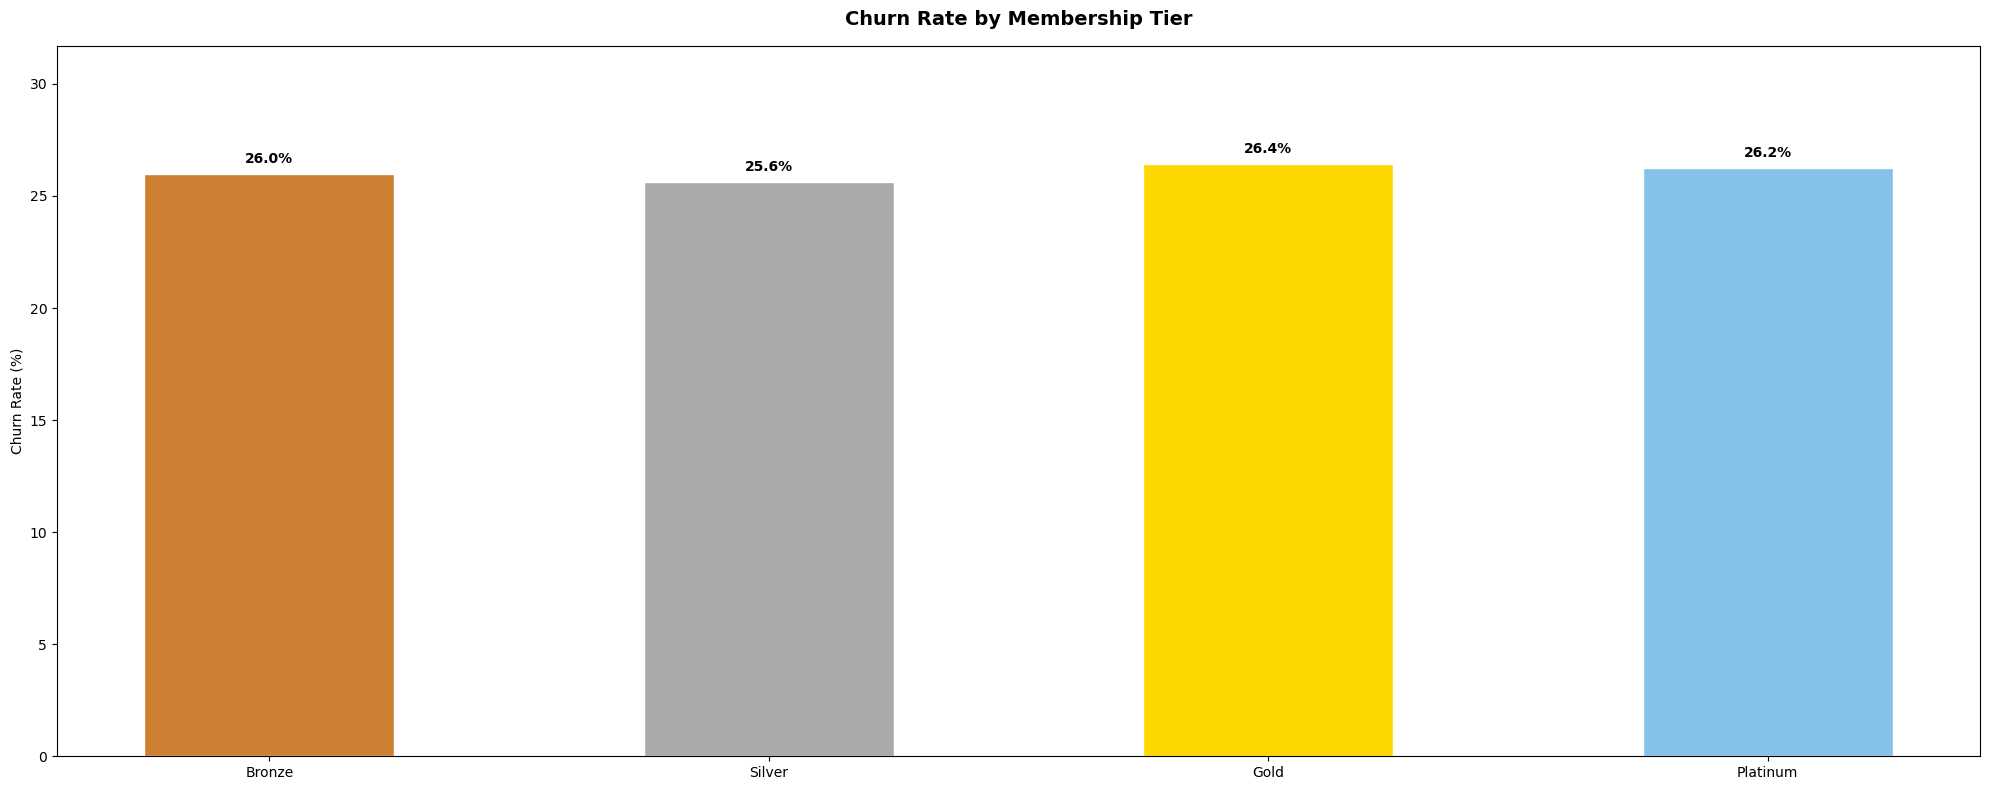


 INSIGHT 2:
 The Churn rate is almost identical across all tiers, staying within a narrow range of 25.6% to 26.4%.
The Gold tier has the highest churn rate (26.4%). Usually, higher loyalty tiers are expected to have lower churn because 
    those customers are more invested. This suggests that the 'Gold' benefits may not be providing enough value to keep those specific 
    customers engaged.
The rewards at the Platinum level, for example, are not significantly reducing churn compared to the entry-level Bronze tier.


In [54]:
fig, ax = plt.subplots(figsize=(20, 8))

tier_order  = ['Bronze', 'Silver', 'Gold', 'Platinum']
tier_colors = ['#cd7f32', '#aaaaaa', '#ffd700', '#85c1e9']
churn_by_tier = df.groupby('membership_tier')['churned'].mean().reindex(tier_order) * 100

bars = ax.bar(tier_order, churn_by_tier.values, color=tier_colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, churn_by_tier.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{val:.1f}%', ha='center', fontweight='bold')

ax.set_title('Churn Rate by Membership Tier', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, churn_by_tier.max() * 1.2)
ax.grid(False)
plt.tight_layout()
plt.show()

print("\n INSIGHT 2:")
print(f" The Churn rate is almost identical across all tiers, staying within a narrow range of 25.6% to 26.4%.")
print(f"""The Gold tier has the highest churn rate (26.4%). Usually, higher loyalty tiers are expected to have lower churn because 
    those customers are more invested. This suggests that the 'Gold' benefits may not be providing enough value to keep those specific 
    customers engaged.""")
print(f"The rewards at the Platinum level, for example, are not significantly reducing churn compared to the entry-level Bronze tier.")

#### CHURN RATE BY CITY

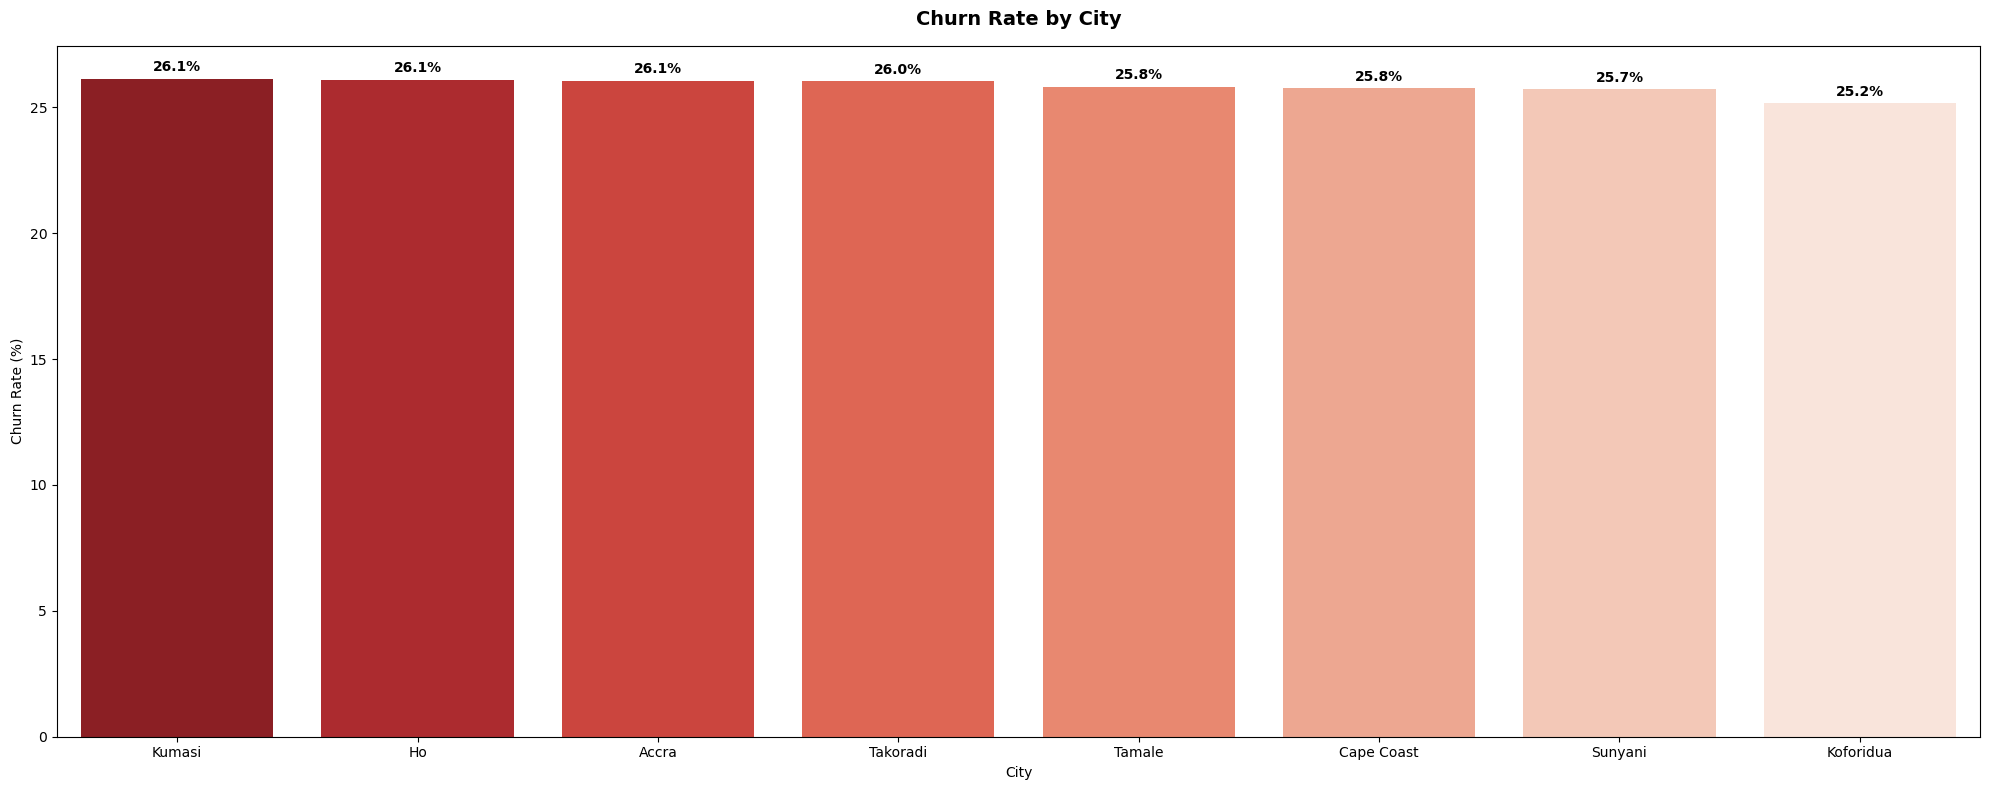


 INSIGHT 3:
  It can be seen that churn rates vary across cities.
  Kumasi has the highest churn which may indicate poor service coverage, delivery issues, or unmet needs in that market.
  Targeted campaigns in high-churn cities can be put in place to recover lost customers.


In [55]:
import warnings
warnings.filterwarnings('ignore')
fig, ax = plt.subplots(figsize=(20, 8))

churn_by_location = (df.groupby('location')['churned'].mean().sort_values(ascending=False) * 100)

sns.barplot(x=churn_by_location.index,
            y=churn_by_location.values,
            palette='Reds_r', ax=ax)

for i, val in enumerate(churn_by_location.values):
    ax.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_title('Churn Rate by City', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('City')
ax.set_ylabel('Churn Rate (%)')
ax.grid(False)
plt.tight_layout()
plt.show()

print("\n INSIGHT 3:")
print(f"  It can be seen that churn rates vary across cities.")
top_city = churn_by_location.idxmax()
print(f"  {top_city} has the highest churn which may indicate poor service coverage, delivery issues, or unmet needs in that market.")
print(f"  Targeted campaigns in high-churn cities can be put in place to recover lost customers.")

#### CHURN RATE BY DEVICE TYPE

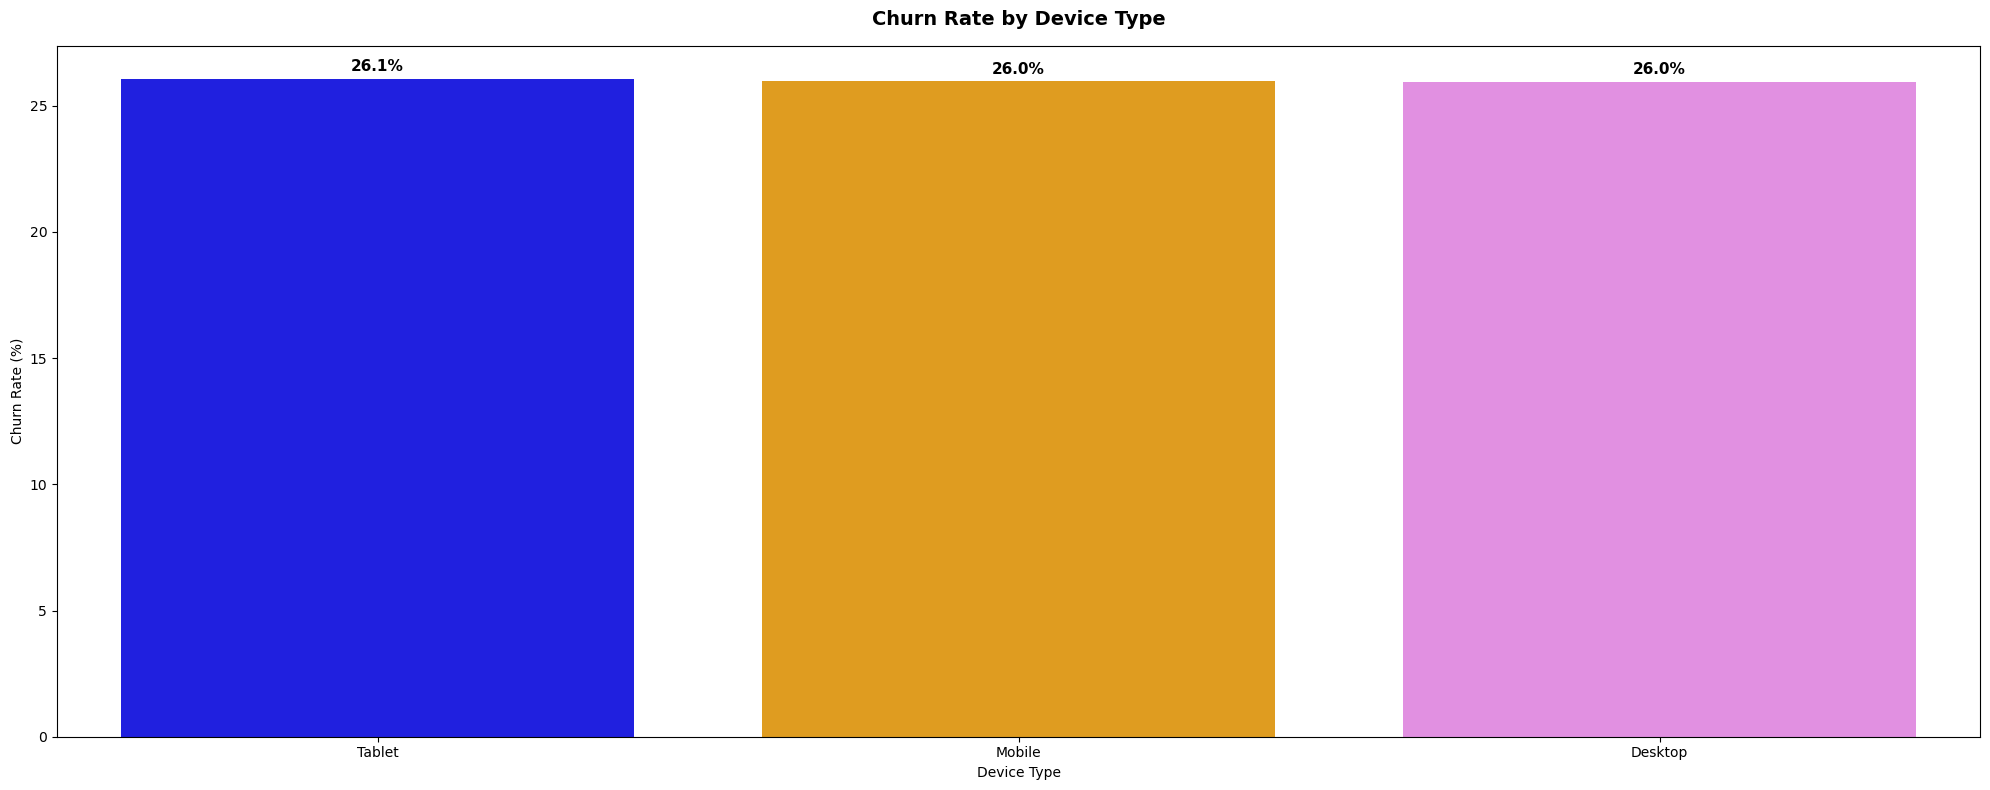


 INSIGHT 4:

INSIGHT 4: Device Impact & Scale
 While churn is uniform across platforms (~26%), Mobile dominates with 60% of total traffic. This uniformity suggests that churn drivers 
are more likely related to product-wide factors (like pricing or catalog) rather than platform-specific technical glitches.
 However, because of the sheer volume, a 1% retention lift on Mobile saves 6x more customers than the same lift on Tablet. Hence, Mobile 
remains the highest-leverage retention surface.


In [56]:
fig, ax = plt.subplots(figsize=(20, 8))

churn_by_device = df.groupby('device_type')['churned'].mean().sort_values(ascending=False) * 100

sns.barplot(x=churn_by_device.index,
            y=churn_by_device.values,
            palette=['blue', 'orange', 'violet'], ax=ax)

for i, val in enumerate(churn_by_device.values):
    ax.text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_title('Churn Rate by Device Type', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Device Type')
ax.set_ylabel('Churn Rate (%)')
ax.grid(False)
plt.tight_layout()
plt.show()

print("\n INSIGHT 4:")
print("\nINSIGHT 4: Device Impact & Scale")
print(f""" While churn is uniform across platforms (~26%), Mobile dominates with 60% of total traffic. This uniformity suggests that churn drivers 
are more likely related to product-wide factors (like pricing or catalog) rather than platform-specific technical glitches.""")
print(f""" However, because of the sheer volume, a 1% retention lift on Mobile saves 6x more customers than the same lift on Tablet. Hence, Mobile 
remains the highest-leverage retention surface.""")

#### TOTAL SPEND DISTRIBUTION

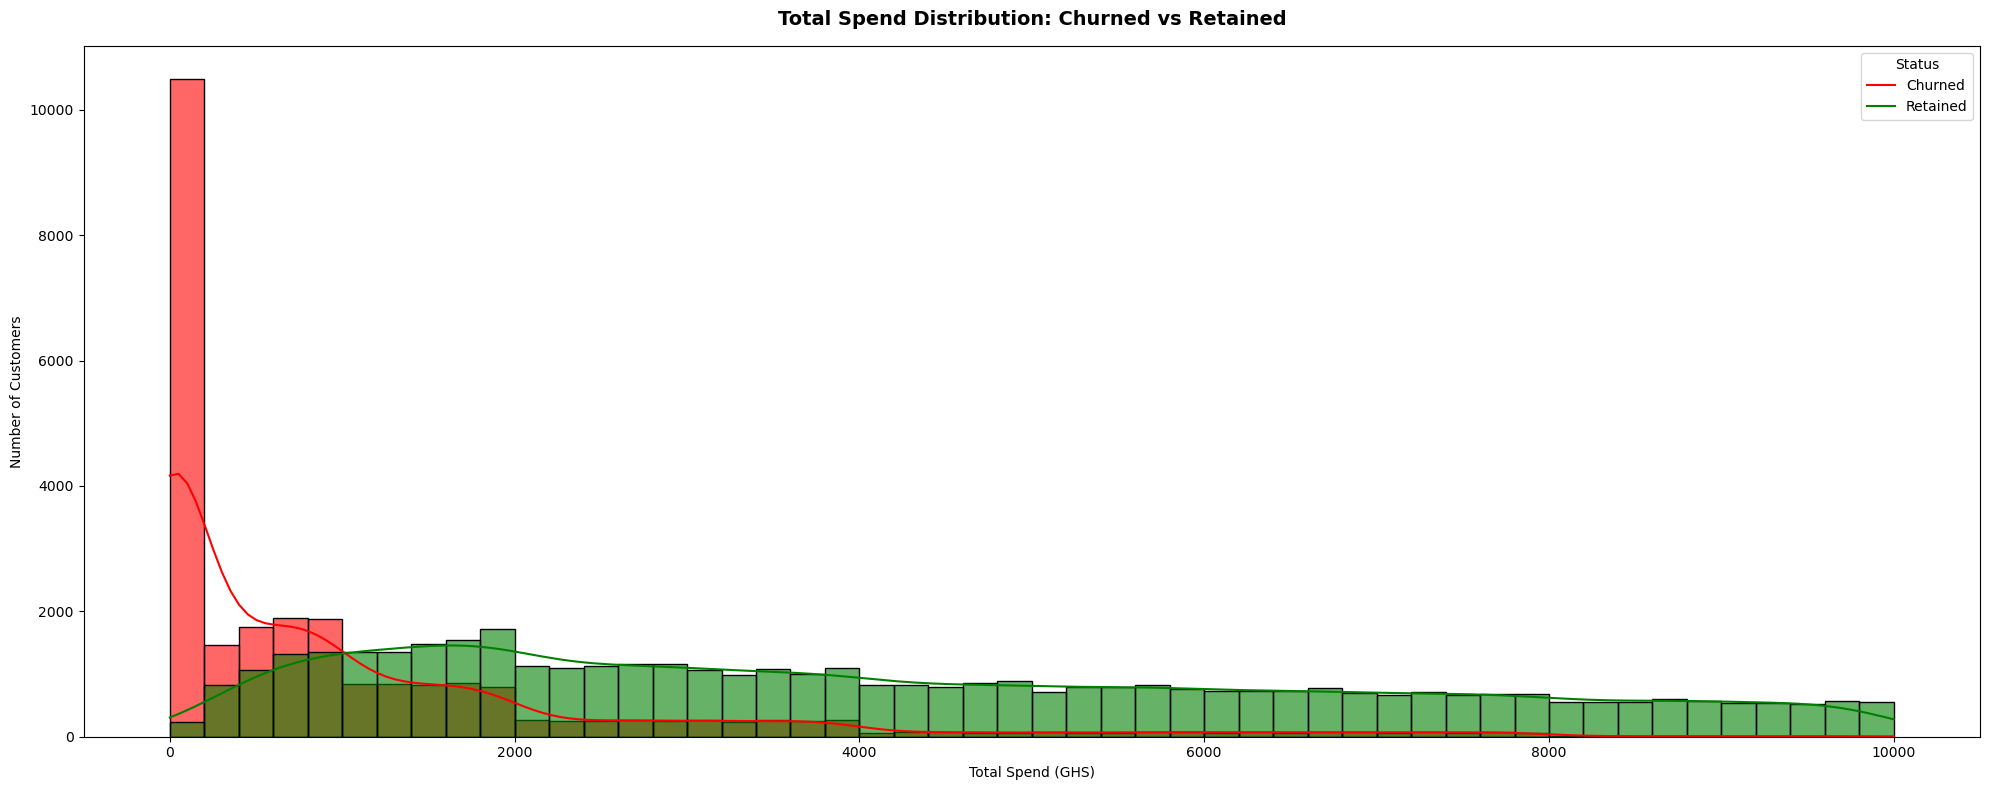


 INSIGHT 5:
  Average spend — Retained: GH₵14,034.78 | Churned: GH₵1,199.17
  The graph shows that churned customers spend significantly less before leaving.
  Early spend decline is a key warning signal to monitor for churn.


In [57]:
fig, ax = plt.subplots(figsize=(20, 8))

# Cap at 10000 for readability (removes extreme outliers visually)
df_plot = df[df['total_spend_ghs'] <= 10000]

sns.histplot(data=df_plot, x='total_spend_ghs', hue='churned',
             bins=50, kde=True, palette={0:'green', 1:'red'},
             alpha=0.6, ax=ax)

ax.set_title('Total Spend Distribution: Churned vs Retained', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Spend (GHS)')
ax.set_ylabel('Number of Customers')
ax.legend(['Churned', 'Retained'], title='Status')
ax.grid(False)
plt.tight_layout()
plt.show()

print("\n INSIGHT 5:")
avg_spend_retained = df[df['churned']==0]['total_spend_ghs'].mean()
avg_spend_churned  = df[df['churned']==1]['total_spend_ghs'].mean()
print(f"  Average spend — Retained: GH₵{avg_spend_retained:,.2f} | Churned: GH₵{avg_spend_churned:,.2f}")
print(f"  The graph shows that churned customers spend significantly less before leaving.")
print(f"  Early spend decline is a key warning signal to monitor for churn.")

#### MODEL CONFUSION MATRIX

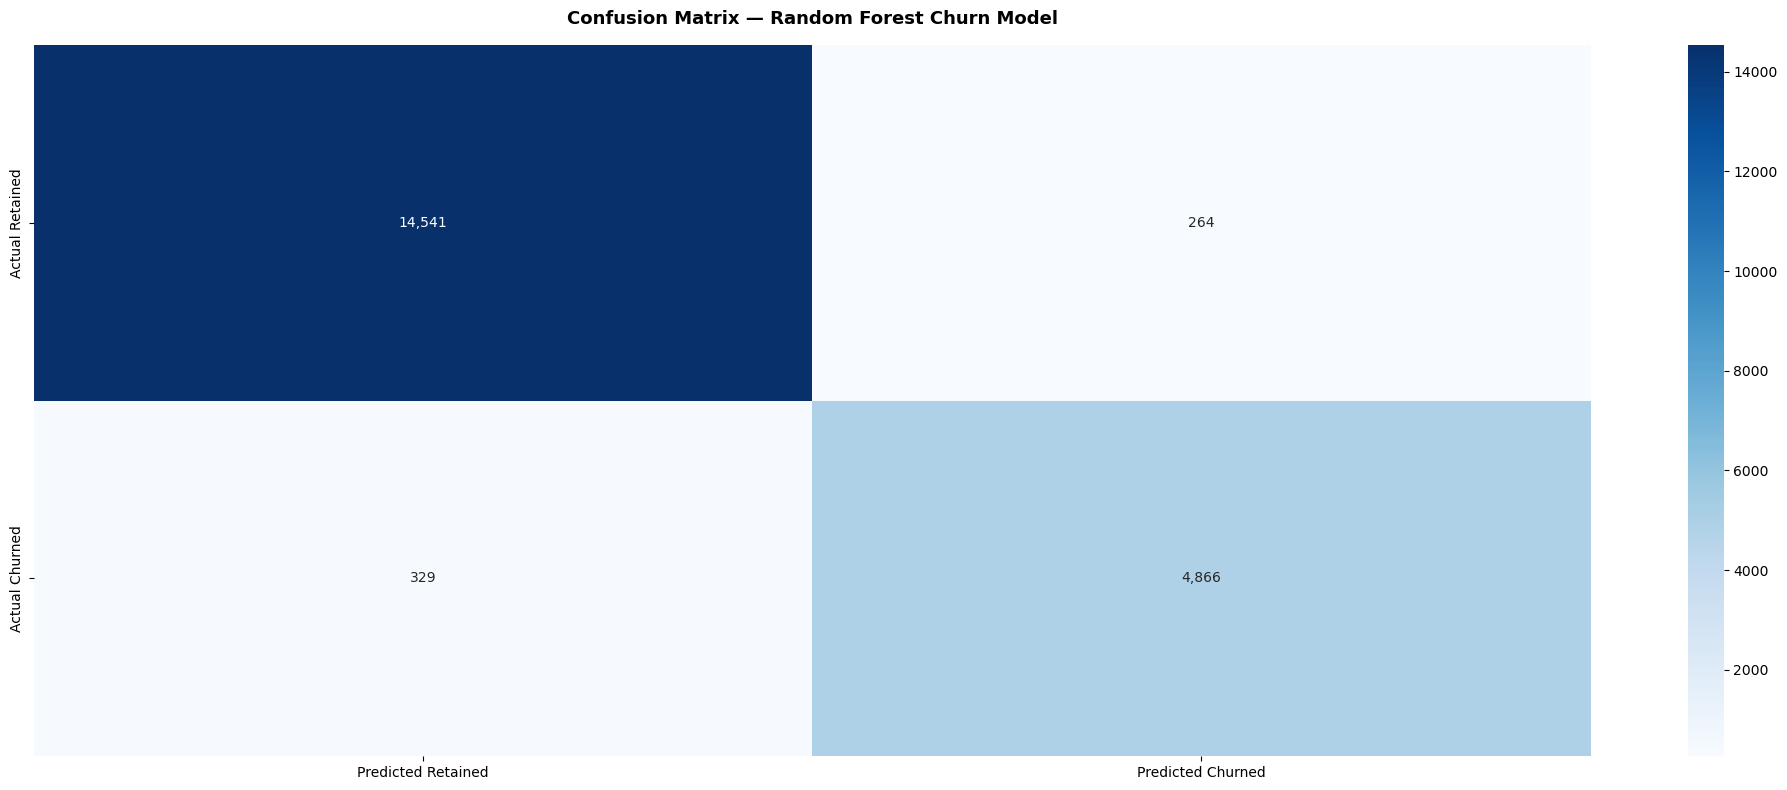


 INSIGHT 6:
  The model correctly identified 4,866 churners out of 5,195 actual churners.
  Only 329 churners were missed (False Negatives).
  This means the business can proactively target 94% of at-risk customers.


In [58]:
fig, ax = plt.subplots(figsize=(20, 8))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt=',', cmap='Blues',
            xticklabels=['Predicted Retained', 'Predicted Churned'],
            yticklabels=['Actual Retained', 'Actual Churned'],
            ax=ax)

ax.set_title('Confusion Matrix — Random Forest Churn Model',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n INSIGHT 6:")
tn, fp, fn, tp = cm.ravel()
print(f"  The model correctly identified {tp:,} churners out of {tp+fn:,} actual churners.")
print(f"  Only {fn:,} churners were missed (False Negatives).")
recall_churned = tp / (tp + fn)
print(f"  This means the business can proactively target {recall_churned:.0%} of at-risk customers.")

#### ROC CURVE

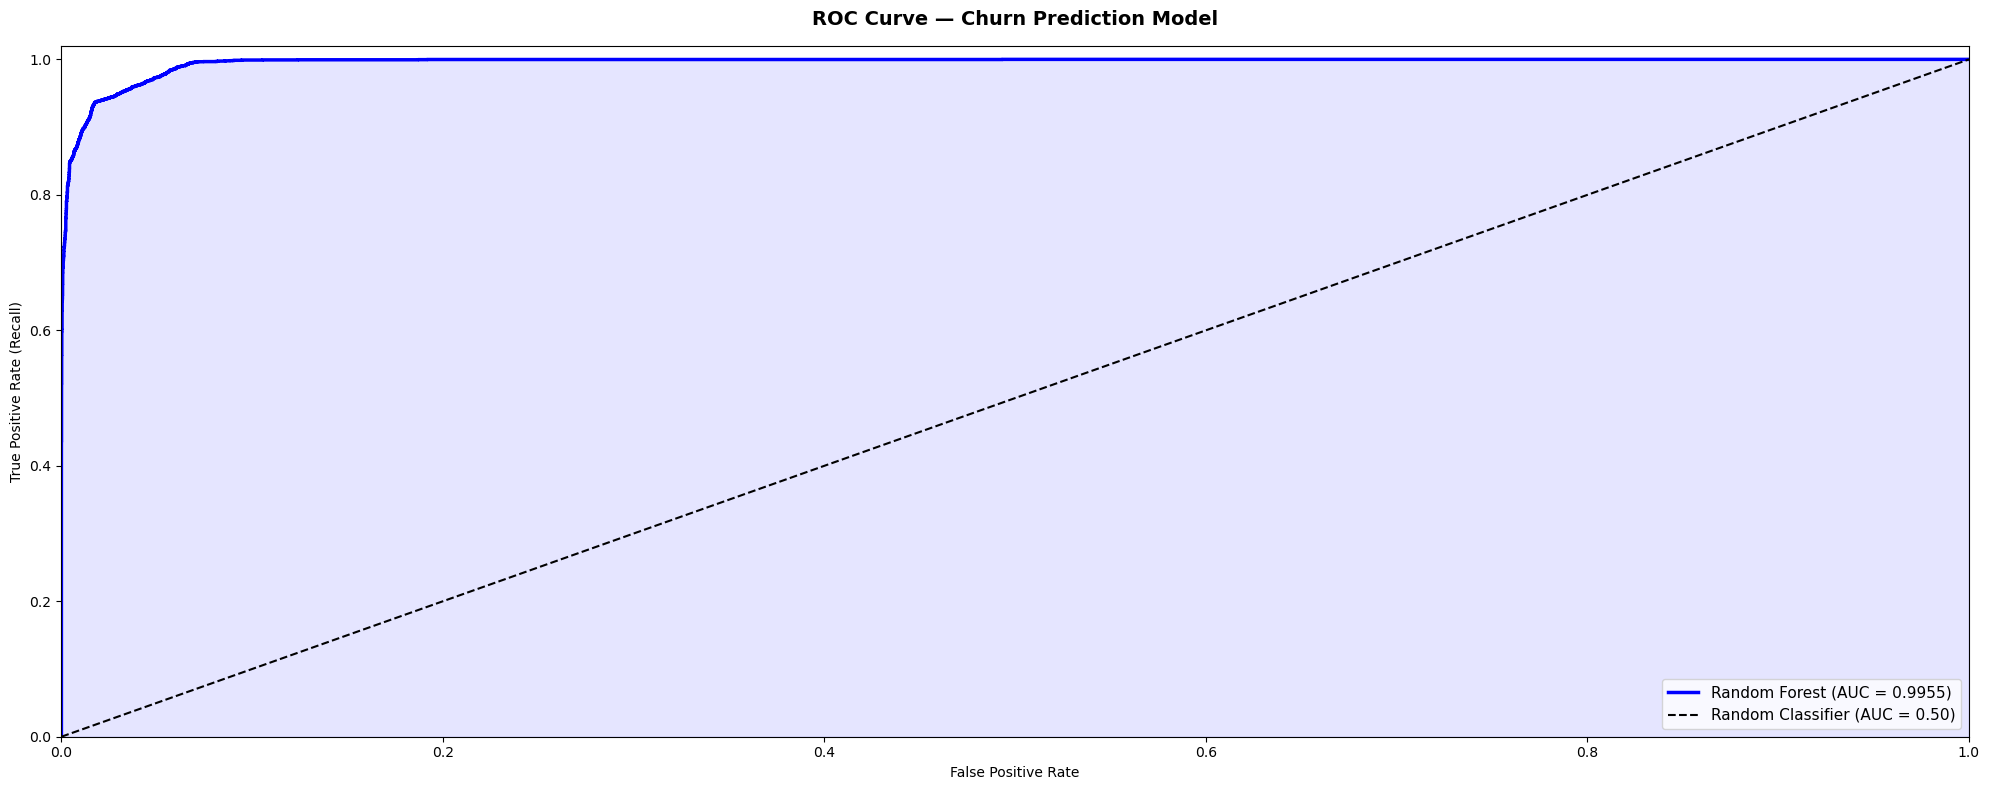


  INSIGHT 7:
  ROC-AUC of 0.9955 means the model has a 99.5% chance of correctly identifying a churner above a retained customer.
  This roc-auc score is above the 0.90 threshold making it an excellent model.


In [59]:
fig, ax = plt.subplots(figsize=(20, 8))

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)

ax.plot(fpr, tpr, color='blue', linewidth=2.5,
        label=f'Random Forest (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Classifier (AUC = 0.50)')
ax.fill_between(fpr, tpr, alpha=0.1, color='blue')

ax.set_title('ROC Curve — Churn Prediction Model', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

print(f"\n  INSIGHT 7:")
print(f"  ROC-AUC of {auc_score:.4f} means the model has a {auc_score*100:.1f}% chance of correctly identifying a churner above a retained customer.")
print(f"  This roc-auc score is above the 0.90 threshold making it an excellent model.")

#### FEATURES DRIVING CHURN

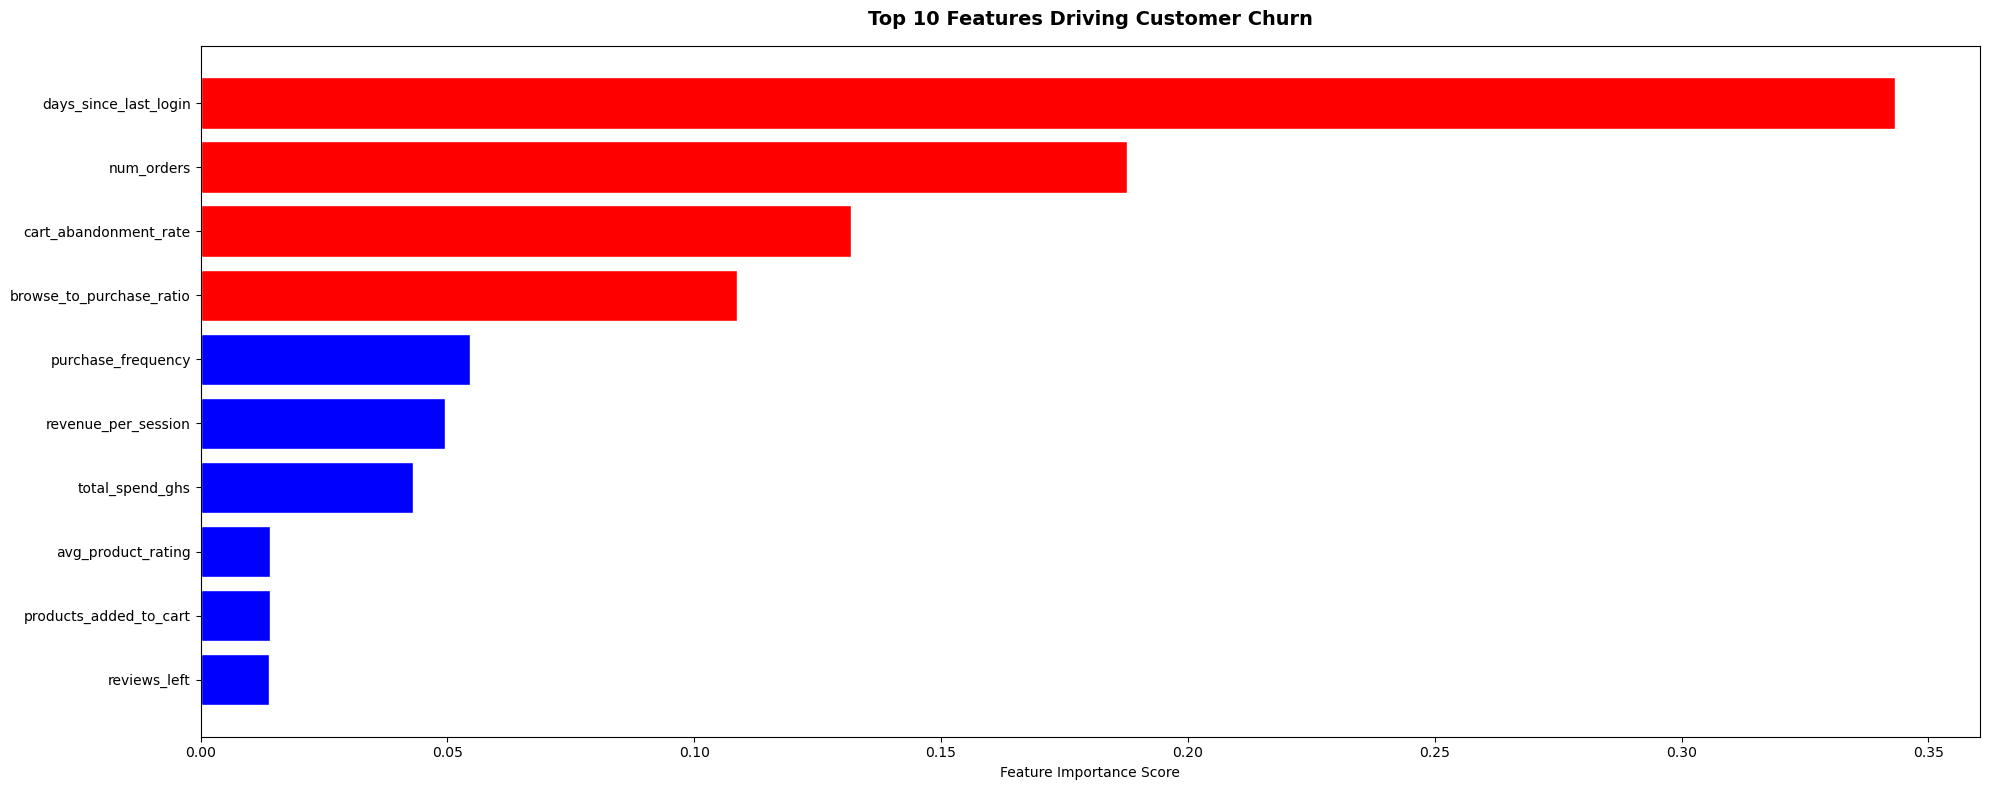


INSIGHT 8:
  The top churn drivers are:
  1. days_since_last_login    — inactivity is the strongest churn signal
  2. num_orders               — low purchase count = high churn risk
  3. cart_abandonment_rate    — browsing without buying = disengagement
  4. browse_to_purchase_ratio — low conversion indicates fading interest
  5. purchase_frequency       — slowing purchase pace = early warning sign


In [60]:
fig, ax = plt.subplots(figsize=(20, 8))

importances = (pd.Series(rf_model.feature_importances_, index=feature_cols)
               .sort_values(ascending=True)
               .tail(10))

colors = ['red' if imp > 0.1 else 'blue' for imp in importances.values]
ax.barh(importances.index, importances.values, color=colors, edgecolor='white')

ax.set_title('Top 10 Features Driving Customer Churn',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Feature Importance Score')
ax.grid(False)
plt.tight_layout()
plt.show()

print("\nINSIGHT 8:")
print("  The top churn drivers are:")
print("  1. days_since_last_login    — inactivity is the strongest churn signal")
print("  2. num_orders               — low purchase count = high churn risk")
print("  3. cart_abandonment_rate    — browsing without buying = disengagement")
print("  4. browse_to_purchase_ratio — low conversion indicates fading interest")
print("  5. purchase_frequency       — slowing purchase pace = early warning sign")

### STEP 8: BUSINESS RECOMMENDATIONS

Based on the analysis and model results, here are five actionable recommendations:

| # | Recommendation | Based On |
|---|---|---|
| 1 | **Re-engagement campaign** - Sending emails or push notifications to customers who are inactive for 45+ days with a personalised discount | `days_since_last_login` is the number one churn driver |
| 2 | **Tier upgrade incentives** - Redesigning Gold and Platinum benefits to provide distinct, high-value retention hooks | Churn is uniform across tiers (~26%), indicating that higher membership levels currently offer no significant "loyalty shield" |
| 3 | **Cart abandonment recovery** - An automated reminder 1 hour after cart is abandoned, with a limited-time offer | `cart_abandonment_rate` is the third biggest churn driver |
| 4 | **City-specific campaigns** - Investing in delivery quality and customer support in high-churn cities | Churn rate varies significantly by location |
| 5 | **Tablet-Specific UX Review** - 60% of users utilize mobile/handheld devices. | Despite this volume, Tablets show the highest churn (26.1%), suggesting that "one-size-fits-all" mobile layouts may be causing friction on larger touchscreens. |

#### Model Deployment Recommendation
Deploy the Random Forest model as a **weekly batch scoring job**:
- Every week, score all active customers on churn probability
- Flag anyone above 0.7 probability as HIGH RISK
- Automatically enroll them in a retention workflow (discount, loyalty points, personal outreach)
- Combine with the Kafka pipeline for real-time flagging of sudden inactivity signals

## Conclusion

This notebook demonstrated a complete intelligent systems pipeline applied to 
e-commerce customer behavior analysis. Key takeaways:

### What Was Built
- A **100,000-row synthetic dataset** with realistic demographic, behavioral, and transactional patterns across 8 Ghanaian cities
- A full **EDA and cleaning pipeline** that identified and resolved missing values, placeholder entries, and data type issues
- **9 engineered features** including engagement score, purchase frequency, browse-to-purchase ratio, and customer lifetime value indicators
- A **Random Forest churn classifier** achieving 97% accuracy and 0.9955 ROC-AUC, validated across 5 cross-validation folds
- A **Kafka streaming simulation** demonstrating real-time event ingestion and churn risk scoring using a Producer-Consumer architecture
- **8 business visualizations** translating model outputs into actionable insights

### Business Impact
The model can identify **94% of churning customers before they leave**, giving the business a window to intervene with targeted retention strategies. 
Combined with the Kafka pipeline for real-time monitoring, this system forms the foundation of a production-ready intelligent customer retention platform.

### Next Steps
- Deploy the model as a weekly batch scoring job
- Integrate Kafka with live website clickstream data
- A/B test retention interventions on high-risk customer segments
- Retrain the model quarterly as new behavioral data accumulates